# Interactive arPLS background subtraction

This notebook is a plotting and parameter-tuning front end for `arpls_background.py`. The numerical functions stay in the Python module; edit the parameters in the next section and then use **Run All**.

Suggested workflow:

1. Choose the input file and fitting energy interval.
2. Optionally set `GAUSSIAN_BLUR_SIGMA` to smooth the baseline-fitting input.
3. Compare candidate $\lambda$ values in the diagnostic plot.
4. Set `ARPLS_LAMBDA` to the preferred value and rerun the notebook.
5. Enable `SAVE_RESULTS` or `SAVE_PLOTS` only when the result looks satisfactory.

Corrected intensities are constrained to be non-negative. Gaussian smoothing affects only background estimation; subtraction is performed from the original unblurred spectrum.

In [11]:
from pathlib import Path
import importlib
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np


def find_background_directory(start: Path) -> Path:
    """Find the folder containing arpls_background.py."""
    start = start.resolve()
    candidates = [start, start / "Background_subtraction"]
    candidates.extend(parent / "Background_subtraction" for parent in start.parents)
    for candidate in candidates:
        if (candidate / "arpls_background.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not find Background_subtraction/arpls_background.py. "
        "Start Jupyter from the project folder or the Background_subtraction folder."
    )


BACKGROUND_DIRECTORY = find_background_directory(Path.cwd())
if str(BACKGROUND_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(BACKGROUND_DIRECTORY))

import arpls_background as bg
bg = importlib.reload(bg)  # pick up edits made after the kernel started

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True})
print(f"Using functions from: {Path(bg.__file__).resolve()}")

Using functions from: /home/zuxian/Documents/MyProjects/EELS_script/Background_subtraction/arpls_background.py


## Parameters

Edit this cell to try a different energy window, spectrum, or arPLS setting. Smaller $\lambda$ gives a more flexible background; larger $\lambda$ gives a smoother background.

In [39]:
# Input and fitting interval
INPUT_FILE = BACKGROUND_DIRECTORY / "SiC_eels_thicknessdata_center_40px_new.npy"
ENERGY_MIN = 180.0       # meV
ENERGY_MAX = 270.0     # meV

# arPLS parameters
ARPLS_LAMBDA = 1e5     # larger = smoother background
ARPLS_RATIO = 1e-6     # convergence tolerance
ARPLS_MAX_ITER = 1000
GAUSSIAN_BLUR_SIGMA = 3.0  # sample points; 0 disables, try 1.0-2.0

# Plot controls
SELECTED_SPECTRUM_INDEX = 0
TEST_LAMBDAS = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
SPECTRUM_LABELS = None  # for example: ["10 nm", "20 nm", ...]

# Saving is deliberately disabled while tuning parameters
SAVE_RESULTS = False
SAVE_PLOTS = False
OUTPUT_NPY_FILE = INPUT_FILE.with_name(f"{INPUT_FILE.stem}_arpls.npy")
OUTPUT_NPZ_FILE = INPUT_FILE.with_name(f"{INPUT_FILE.stem}_arpls_full.npz")
PLOT_DIRECTORY = BACKGROUND_DIRECTORY / "arpls_plots"

## Load data and select the fitting interval

In [40]:
data, energy, intensities = bg.load_spectra(INPUT_FILE)
n_spectra = data.shape[0]

if SPECTRUM_LABELS is not None and len(SPECTRUM_LABELS) != n_spectra:
    raise ValueError(
        f"SPECTRUM_LABELS contains {len(SPECTRUM_LABELS)} labels, "
        f"but the file contains {n_spectra} spectra."
    )
if not 0 <= SELECTED_SPECTRUM_INDEX < n_spectra:
    raise IndexError(
        f"SELECTED_SPECTRUM_INDEX must be between 0 and {n_spectra - 1}."
    )

energy_mask, energy_selected, intensity_selected = bg.select_energy_range(
    energy, intensities, ENERGY_MIN, ENERGY_MAX
)
fit_intensity_selected = bg.gaussian_blur_spectra(
    intensity_selected, sigma=GAUSSIAN_BLUR_SIGMA
)

print(f"Loaded: {INPUT_FILE.name}")
print(f"Data shape: {data.shape} ({n_spectra} spectra)")
print(
    f"Fit interval: {energy_selected[0]:.3f} to {energy_selected[-1]:.3f} meV "
    f"({energy_selected.size} points)"
)

Loaded: SiC_eels_thicknessdata_center_40px_new.npy
Data shape: (4, 600, 2) (4 spectra)
Fit interval: 180.131 to 269.278 meV (98 points)


## Compare candidate $\lambda$ values

The colored curves are candidate backgrounds for the selected spectrum. Adjust `TEST_LAMBDAS` above until the useful range is clear.

lambda=1e+03: iterations=88, converged=True, reason=converged
lambda=1e+04: iterations=98, converged=True, reason=converged
lambda=1e+05: iterations=26, converged=True, reason=converged
lambda=1e+06: iterations=19, converged=True, reason=converged
lambda=1e+07: iterations=18, converged=True, reason=converged
lambda=1e+08: iterations=18, converged=True, reason=converged


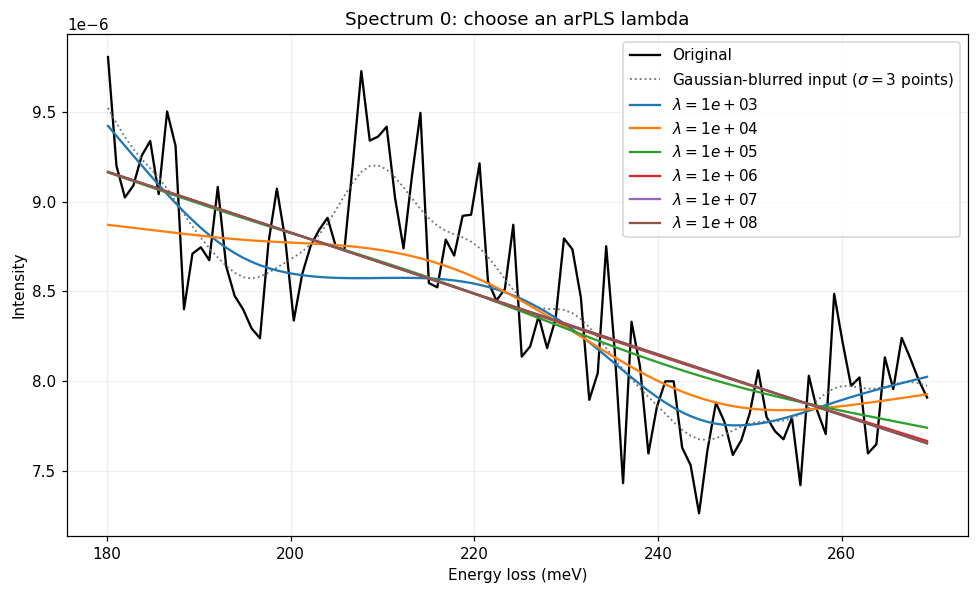

In [41]:
lambda_figure, lambda_infos = bg.plot_lambda_diagnostics(
    energy_selected,
    intensity_selected[SELECTED_SPECTRUM_INDEX],
    TEST_LAMBDAS,
    ratio=ARPLS_RATIO,
    max_iter=ARPLS_MAX_ITER,
    gaussian_sigma=GAUSSIAN_BLUR_SIGMA,
)
lambda_figure.axes[0].set_title(
    f"Spectrum {SELECTED_SPECTRUM_INDEX}: choose an arPLS lambda"
)

for lam, info in zip(TEST_LAMBDAS, lambda_infos):
    print(
        f"lambda={lam:.0e}: iterations={info['iterations']}, "
        f"converged={info['converged']}, "
        f"reason={info['termination_reason']}"
    )
plt.show()

## Fit all spectra

After choosing `ARPLS_LAMBDA`, this cell applies the same settings to every spectrum in the selected energy interval.

In [33]:
background_selected, corrected_selected, fit_infos = bg.apply_arpls_to_spectra(
    intensity_selected,
    lam=ARPLS_LAMBDA,
    ratio=ARPLS_RATIO,
    max_iter=ARPLS_MAX_ITER,
    gaussian_sigma=GAUSSIAN_BLUR_SIGMA,
)

for index, info in enumerate(fit_infos):
    print(
        f"Spectrum {index}: iterations={info['iterations']}, "
        f"converged={info['converged']}, "
        f"relative change={info['relative_weight_change']:.3e}, "
        f"reason={info['termination_reason']}, "
        f"negative points clipped={info['negative_points_clipped']}"
    )
    if not info["converged"]:
        warnings.warn(
            f"arPLS did not converge for spectrum {index}: "
            f"{info['termination_reason']}",
            RuntimeWarning,
        )

Spectrum 0: iterations=35, converged=False, relative change=3.424e-01, reason=too_few_negative_residuals, negative points clipped=32
Spectrum 1: iterations=32, converged=True, relative change=7.083e-07, reason=converged, negative points clipped=33
Spectrum 2: iterations=46, converged=False, relative change=2.209e-03, reason=too_few_negative_residuals, negative points clipped=38
Spectrum 3: iterations=37, converged=False, relative change=7.471e-02, reason=too_few_negative_residuals, negative points clipped=30


/tmp/ipykernel_30366/1611125627.py:18: RuntimeWarning: arPLS did not converge for spectrum 0: too_few_negative_residuals
  warnings.warn(
/tmp/ipykernel_30366/1611125627.py:18: RuntimeWarning: arPLS did not converge for spectrum 2: too_few_negative_residuals
  warnings.warn(
/tmp/ipykernel_30366/1611125627.py:18: RuntimeWarning: arPLS did not converge for spectrum 3: too_few_negative_residuals
  warnings.warn(


## Inspect one spectrum

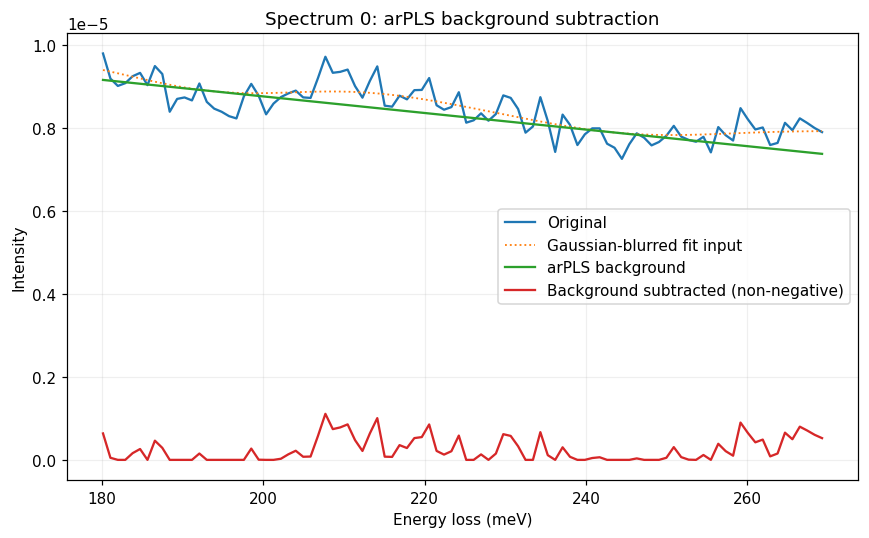

In [34]:
selected_label = (
    None if SPECTRUM_LABELS is None else SPECTRUM_LABELS[SELECTED_SPECTRUM_INDEX]
)
selected_figure, _ = bg.plot_spectrum_result(
    energy_selected,
    intensity_selected[SELECTED_SPECTRUM_INDEX],
    background_selected[SELECTED_SPECTRUM_INDEX],
    corrected_selected[SELECTED_SPECTRUM_INDEX],
    spectrum_index=SELECTED_SPECTRUM_INDEX,
    label=selected_label,
    fit_intensity=(
        fit_intensity_selected[SELECTED_SPECTRUM_INDEX]
        if GAUSSIAN_BLUR_SIGMA > 0 else None
    ),
)
plt.show()

## Compare all spectra

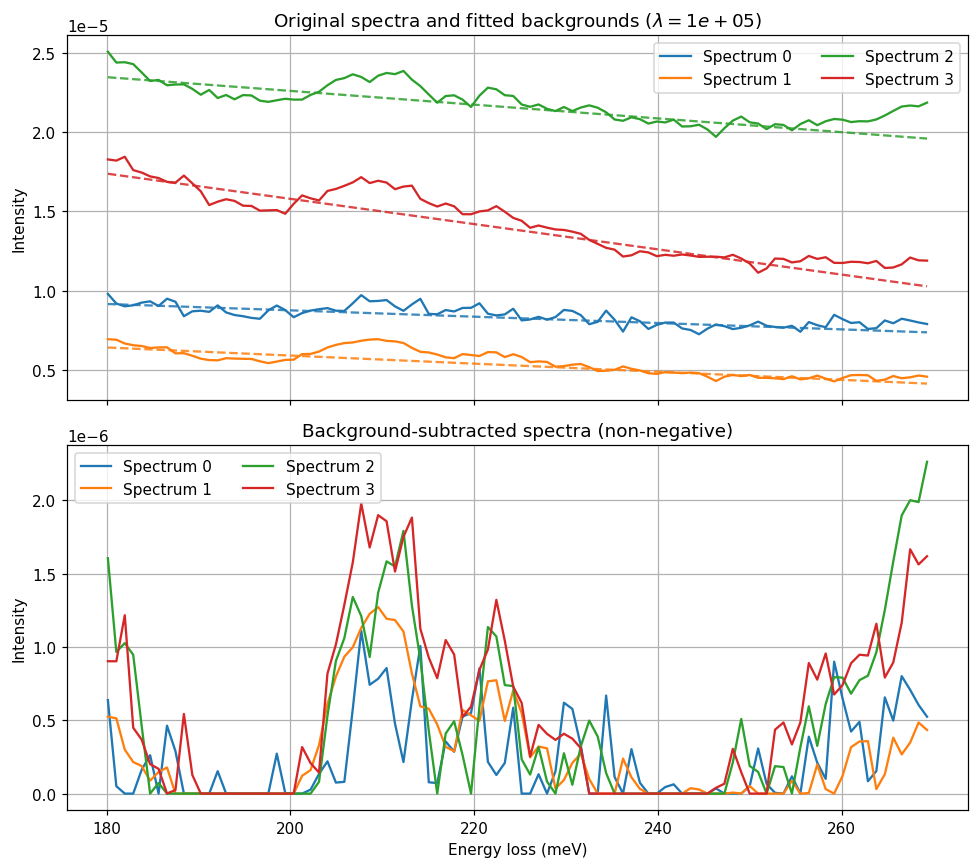

In [35]:
overview_figure, (original_axes, corrected_axes) = plt.subplots(
    2, 1, figsize=(9, 8), sharex=True
)

for index in range(n_spectra):
    label = str(index) if SPECTRUM_LABELS is None else SPECTRUM_LABELS[index]
    line = original_axes.plot(
        energy_selected, intensity_selected[index], label=f"Spectrum {label}"
    )[0]
    original_axes.plot(
        energy_selected,
        background_selected[index],
        linestyle="--",
        color=line.get_color(),
        alpha=0.85,
    )
    corrected_axes.plot(
        energy_selected, corrected_selected[index], label=f"Spectrum {label}"
    )

original_axes.set_title(
    fr"Original spectra and fitted backgrounds ($\lambda={ARPLS_LAMBDA:.0e}$)"
)
original_axes.set_ylabel("Intensity")
original_axes.legend(ncol=2)
corrected_axes.set_title("Background-subtracted spectra (non-negative)")
corrected_axes.set_xlabel("Energy loss (meV)")
corrected_axes.set_ylabel("Intensity")
corrected_axes.legend(ncol=2)
overview_figure.tight_layout()
plt.show()

## Optional saving

Set `SAVE_RESULTS` and/or `SAVE_PLOTS` to `True` in the parameter cell, then rerun the notebook. In the convenience NPY output, values outside the selected interval remain unchanged. The NPZ output explicitly stores `NaN` outside the fitted interval and is preferred for quantitative analysis.

In [ ]:
if SAVE_RESULTS:
    bg.save_results(
        data=data,
        energy=energy,
        intensities=intensities,
        energy_mask=energy_mask,
        background_selected=background_selected,
        corrected_selected=corrected_selected,
        output_npy_file=OUTPUT_NPY_FILE,
        output_npz_file=OUTPUT_NPZ_FILE,
        energy_min=ENERGY_MIN,
        energy_max=ENERGY_MAX,
        arpls_lambda=ARPLS_LAMBDA,
        arpls_ratio=ARPLS_RATIO,
        arpls_max_iter=ARPLS_MAX_ITER,
        gaussian_blur_sigma=GAUSSIAN_BLUR_SIGMA,
    )
    print(f"Saved results to {OUTPUT_NPY_FILE} and {OUTPUT_NPZ_FILE}")
else:
    print("Results were not saved (SAVE_RESULTS=False).")

if SAVE_PLOTS:
    PLOT_DIRECTORY.mkdir(parents=True, exist_ok=True)
    lambda_figure.savefig(
        PLOT_DIRECTORY / f"spectrum_{SELECTED_SPECTRUM_INDEX}_lambda_diagnostic.png",
        dpi=200,
        bbox_inches="tight",
    )
    selected_figure.savefig(
        PLOT_DIRECTORY / f"spectrum_{SELECTED_SPECTRUM_INDEX}_arpls.png",
        dpi=200,
        bbox_inches="tight",
    )
    overview_figure.savefig(
        PLOT_DIRECTORY / "all_spectra_arpls_overview.png",
        dpi=200,
        bbox_inches="tight",
    )
    print(f"Saved plots to {PLOT_DIRECTORY}")
else:
    print("Plots were not saved (SAVE_PLOTS=False).")